# Zava Retail Analysis Dashboard

This single notebook is the polished one-page version of the full analysis workflow.

Recommended presentation flow:
1. Seasonal demand patterns
2. Store alignment to national seasonality
3. 2023 sales snapshot
4. Product affinity and bundling
5. Inventory risk by store
6. Products with the widest inventory gap
7. RLS comparison for super manager vs store manager

Each section connects to the live PostgreSQL database and shows the result as a table and, where useful, an inline chart.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from psycopg2.extras import RealDictCursor

DB_CONFIG = {
    'host': 'db',
    'port': 5432,
    'dbname': 'zava',
    'user': 'postgres',
    'password': 'P@ssw0rd!',
}

def fetch_query(query, params=None):
    conn = psycopg2.connect(**DB_CONFIG)
    try:
        with conn.cursor(cursor_factory=RealDictCursor) as cur:
            if params is None:
                cur.execute(query)
            else:
                cur.execute(query, params)
            rows = cur.fetchall()
    finally:
        conn.close()
    return pd.DataFrame(rows)

def fetch_scalar(query, params=None):
    df = fetch_query(query, params)
    return df.iloc[0].to_dict() if not df.empty else {}

print('Database session ready for analysis.')

Database session ready for analysis.


## 1) Seasonal Demand Pattern

This ranks categories by the difference between their highest and lowest average monthly seasonal indices. Each complete calendar year is normalized to that year's category average before the indices are averaged, reducing distortion from year-over-year growth. The data identifies the peak month, but it contains no supplier or replenishment lead times, so it cannot determine how many weeks or months ahead to place orders.

In [10]:
seasonal_sql = """
WITH eligible_years AS (
    SELECT EXTRACT(YEAR FROM order_date)::int AS year_num
    FROM retail.orders
    GROUP BY EXTRACT(YEAR FROM order_date)::int
    HAVING COUNT(DISTINCT EXTRACT(MONTH FROM order_date)) = 12
),
monthly_category_sales AS (
    SELECT
        c.category_id,
        c.category_name,
        EXTRACT(YEAR FROM o.order_date)::int AS year_num,
        EXTRACT(MONTH FROM o.order_date)::int AS month_num,
        SUM(oi.quantity)::numeric AS units_sold
    FROM retail.orders o
    JOIN retail.order_items oi
      ON oi.order_id = o.order_id
    JOIN retail.products p
      ON p.product_id = oi.product_id
    JOIN retail.categories c
      ON c.category_id = p.category_id
    JOIN eligible_years y
      ON y.year_num = EXTRACT(YEAR FROM o.order_date)::int
    GROUP BY c.category_id, c.category_name,
             EXTRACT(YEAR FROM o.order_date)::int,
             EXTRACT(MONTH FROM o.order_date)::int
),
month_names AS (
    SELECT * FROM (VALUES
        (1, 'Jan'), (2, 'Feb'), (3, 'Mar'), (4, 'Apr'),
        (5, 'May'), (6, 'Jun'), (7, 'Jul'), (8, 'Aug'),
        (9, 'Sep'), (10, 'Oct'), (11, 'Nov'), (12, 'Dec')
    ) AS m(month_num, month_name)
),
category_months AS (
    SELECT
        cat.category_id,
        cat.category_name,
        y.year_num,
        m.month_num,
        m.month_name,
        COALESCE(s.units_sold, 0) AS units_sold
    FROM retail.categories cat
    CROSS JOIN eligible_years y
    CROSS JOIN month_names m
    LEFT JOIN monthly_category_sales s
      ON s.category_id = cat.category_id
     AND s.year_num = y.year_num
     AND s.month_num = m.month_num
),
yearly_indices AS (
    SELECT
        category_id,
        category_name,
        year_num,
        month_num,
        month_name,
        units_sold / NULLIF(AVG(units_sold) OVER (PARTITION BY category_id, year_num), 0) AS seasonal_index
    FROM category_months
),
average_monthly_indices AS (
    SELECT
        category_id,
        category_name,
        month_num,
        month_name,
        AVG(seasonal_index) AS seasonal_index
    FROM yearly_indices
    WHERE seasonal_index IS NOT NULL
    GROUP BY category_id, category_name, month_num, month_name
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY category_id ORDER BY seasonal_index DESC, month_num) AS peak_rank,
        ROW_NUMBER() OVER (PARTITION BY category_id ORDER BY seasonal_index ASC, month_num) AS low_rank
    FROM average_monthly_indices
),
summary AS (
    SELECT
        category_id,
        category_name,
        MAX(seasonal_index) - MIN(seasonal_index) AS seasonal_swing
    FROM ranked
    GROUP BY category_id, category_name
)
SELECT
    s.category_name,
    s.seasonal_swing,
    MAX(r.month_name) FILTER (WHERE r.peak_rank = 1) AS peak_month,
    MAX(r.month_name) FILTER (WHERE r.low_rank = 1) AS low_month
FROM summary s
JOIN ranked r
  ON r.category_id = s.category_id
GROUP BY s.category_id, s.category_name, s.seasonal_swing
ORDER BY s.seasonal_swing DESC;
"""
seasonal_df = fetch_query(seasonal_sql)
seasonal_df
top_seasonal_category = seasonal_df.iloc[0]
print(
    f"Sharpest swing: {top_seasonal_category['category_name']} "
    f"(swing {top_seasonal_category['seasonal_swing']:.3f}), "
    f"peaking in {top_seasonal_category['peak_month']} and lowest in {top_seasonal_category['low_month']}. "
    "The database has no supplier lead-time data, so advance purchasing time cannot be calculated."
)

Sharpest swing: GARDEN & OUTDOOR (swing 0.948), peaking in Apr and lowest in Dec. The database has no supplier lead-time data, so advance purchasing time cannot be calculated.


In [98]:
validation_years_df = fetch_query("""
SELECT EXTRACT(YEAR FROM order_date)::int AS year_num
FROM retail.orders
GROUP BY EXTRACT(YEAR FROM order_date)::int
HAVING COUNT(DISTINCT EXTRACT(MONTH FROM order_date)) = 12
ORDER BY year_num;
""")
validation_categories_df = fetch_query("SELECT category_id, category_name FROM retail.categories;")
validation_raw_months_df = fetch_query("""
SELECT
    c.category_id,
    c.category_name,
    EXTRACT(YEAR FROM o.order_date)::int AS year_num,
    EXTRACT(MONTH FROM o.order_date)::int AS month_num,
    SUM(oi.quantity)::numeric AS units_sold
FROM retail.orders o
JOIN retail.order_items oi
  ON oi.order_id = o.order_id
JOIN retail.products p
  ON p.product_id = oi.product_id
JOIN retail.categories c
  ON c.category_id = p.category_id
GROUP BY c.category_id, c.category_name,
         EXTRACT(YEAR FROM o.order_date)::int,
         EXTRACT(MONTH FROM o.order_date)::int;
""")

validation_grid_df = pd.MultiIndex.from_product(
    [validation_categories_df['category_id'], validation_years_df['year_num'], range(1, 13)],
    names=['category_id', 'year_num', 'month_num']
).to_frame(index=False)
validation_months_df = (
    validation_grid_df
    .merge(validation_categories_df, on='category_id')
    .merge(
        validation_raw_months_df,
        on=['category_id', 'category_name', 'year_num', 'month_num'],
        how='left'
    )
)
validation_months_df['units_sold'] = validation_months_df['units_sold'].fillna(0).astype(float)
validation_months_df['year_average'] = validation_months_df.groupby(
    ['category_id', 'year_num']
)['units_sold'].transform('mean')
validation_months_df['seasonal_index'] = (
    validation_months_df['units_sold'] /
    validation_months_df['year_average'].where(validation_months_df['year_average'] != 0)
)
validation_monthly_indices_df = (
    validation_months_df
    .groupby(['category_id', 'category_name', 'month_num'], as_index=False)['seasonal_index']
    .mean()
)
validation_swings_df = (
    validation_monthly_indices_df
    .groupby(['category_id', 'category_name'], as_index=False)['seasonal_index']
    .agg(seasonal_swing=lambda values: values.max() - values.min())
)
validation_peaks_df = (
    validation_monthly_indices_df
    .sort_values(['category_id', 'seasonal_index', 'month_num'], ascending=[True, False, True])
    .groupby('category_id', as_index=False)
    .first()[['category_id', 'month_num']]
    .rename(columns={'month_num': 'peak_month_num'})
)
validation_lows_df = (
    validation_monthly_indices_df
    .sort_values(['category_id', 'seasonal_index', 'month_num'], ascending=[True, True, True])
    .groupby('category_id', as_index=False)
    .first()[['category_id', 'month_num']]
    .rename(columns={'month_num': 'low_month_num'})
)
month_labels = dict(enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    start=1
))
validation_expected_df = (
    validation_swings_df
    .merge(validation_peaks_df, on='category_id')
    .merge(validation_lows_df, on='category_id')
)
validation_expected_df['peak_month'] = validation_expected_df['peak_month_num'].map(month_labels)
validation_expected_df['low_month'] = validation_expected_df['low_month_num'].map(month_labels)
validation_compare_df = seasonal_df.merge(
    validation_expected_df[['category_name', 'seasonal_swing', 'peak_month', 'low_month']],
    on='category_name',
    suffixes=('_sql', '_pandas')
)
validation_compare_df['swing_difference'] = (
    validation_compare_df['seasonal_swing_sql'].astype(float)
    - validation_compare_df['seasonal_swing_pandas']
)
assert validation_compare_df['swing_difference'].abs().max() < 1e-9
assert (validation_compare_df['peak_month_sql'] == validation_compare_df['peak_month_pandas']).all()
assert (validation_compare_df['low_month_sql'] == validation_compare_df['low_month_pandas']).all()
display(validation_compare_df.sort_values('seasonal_swing_sql', ascending=False))
print('PASS: SQL seasonal swings and peak/low months match an independent pandas recomputation.')

,category_name,seasonal_swing_sql,peak_month_sql,low_month_sql,seasonal_swing_pandas,peak_month_pandas,low_month_pandas,swing_difference
0,GARDEN & OUTDOOR,0.94789276518552413751,Apr,Dec,0.947893,Apr,Dec,0.000000e+00
1,STORAGE & ORGANIZATION,0.89052494103919146917,Feb,Jun,0.890525,Feb,Jun,0.000000e+00
2,LUMBER & BUILDING MATERIALS,0.62122458982576306026,Jun,Dec,0.621225,Jun,Dec,0.000000e+00
3,ELECTRICAL,0.55156852198398779411,Dec,Apr,0.551569,Dec,Apr,2.220446e-16
4,HARDWARE,0.54672035332644341064,Oct,Jul,0.546720,Oct,Jul,1.110223e-16
5,POWER TOOLS,0.51524704106225412018,Aug,Dec,0.515247,Aug,Dec,1.110223e-16
6,PLUMBING,0.43518070633664543869,Oct,Aug,0.435181,Oct,Aug,1.665335e-16
7,PAINT & FINISHES,0.40014314436875415502,Mar,Nov,0.400143,Mar,Nov,-5.551115e-17
8,HAND TOOLS,0.23279154211445079973,Jul,Oct,0.232792,Jul,Oct,-5.551115e-17


PASS: SQL seasonal swings and peak/low months match an independent pandas recomputation.


`seasonal_swing` is the peak-to-low range of the normalized monthly index. A value of 0.948 means a spread of about 94.8 percentage points relative to average monthly demand; it is not a unit count or a percentage increase from the low month.

,category_name,seasonal_swing,peak_month,low_month
0,GARDEN & OUTDOOR,0.948,Apr,Dec
1,STORAGE & ORGANIZATION,0.891,Feb,Jun
2,LUMBER & BUILDING MATERIALS,0.621,Jun,Dec
3,ELECTRICAL,0.552,Dec,Apr
4,HARDWARE,0.547,Oct,Jul
5,POWER TOOLS,0.515,Aug,Dec
6,PLUMBING,0.435,Oct,Aug
7,PAINT & FINISHES,0.400,Mar,Nov
8,HAND TOOLS,0.233,Jul,Oct


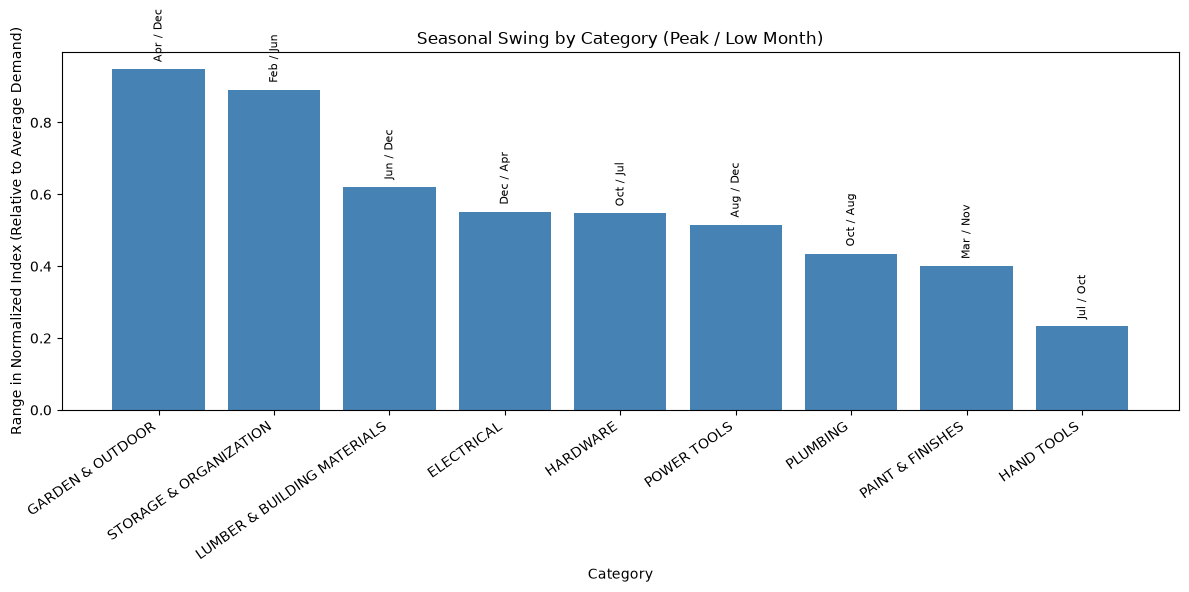

In [100]:
seasonal_display_df = seasonal_df.copy()
seasonal_display_df['seasonal_swing'] = seasonal_display_df['seasonal_swing'].map(lambda value: f'{value:.3f}')
display(seasonal_display_df)

seasonal_plot_df = seasonal_df.copy()

# Add concise month labels so the peak and low month are visible in the chart itself.
seasonal_plot_df['month_label'] = seasonal_plot_df['peak_month'] + ' / ' + seasonal_plot_df['low_month']

plt.figure(figsize=(12, 6))
bars = plt.bar(seasonal_plot_df['category_name'], seasonal_plot_df['seasonal_swing'], color='steelblue')

for bar, row in zip(bars, seasonal_plot_df.itertuples()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{row.peak_month} / {row.low_month}",
        ha='center',
        va='bottom',
        rotation=90,
        fontsize=8,
        color='black'
    )

plt.title('Seasonal Swing by Category (Peak / Low Month)')
plt.xlabel('Category')
plt.ylabel('Range in Normalized Index (Relative to Average Demand)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 2) Store Alignment to National Seasonality

This compares each store's observed category-by-month sales pattern with the database-wide pattern. The deviation is calculated from actual order quantities; a lower value means the store's seasonal pattern is closer to the national pattern. The companion table reports customer assignment and observed sales-volume shares from the database; these describe store size and do not feed into the alignment score.

In [12]:
store_pattern_sql = """
WITH monthly_store_category_sales AS (
    SELECT
        s.store_id,
        s.store_name,
        c.category_id,
        c.category_name,
        EXTRACT(MONTH FROM o.order_date)::int AS month_num,
        SUM(oi.quantity)::numeric AS units_sold
    FROM retail.orders o
    JOIN retail.order_items oi
      ON oi.order_id = o.order_id
    JOIN retail.products p
      ON p.product_id = oi.product_id
    JOIN retail.categories c
      ON c.category_id = p.category_id
    JOIN retail.stores s
      ON s.store_id = o.store_id
    GROUP BY s.store_id, s.store_name, c.category_id, c.category_name,
             EXTRACT(MONTH FROM o.order_date)::int
),
store_category_months AS (
    SELECT
        s.store_id,
        s.store_name,
        c.category_id,
        c.category_name,
        m.month_num,
        COALESCE(ms.units_sold, 0) AS units_sold
    FROM retail.stores s
    CROSS JOIN retail.categories c
    CROSS JOIN generate_series(1, 12) AS m(month_num)
    LEFT JOIN monthly_store_category_sales ms
      ON ms.store_id = s.store_id
     AND ms.category_id = c.category_id
     AND ms.month_num = m.month_num
),
national_category_months AS (
    SELECT
        category_id,
        month_num,
        SUM(units_sold) AS units_sold
    FROM store_category_months
    GROUP BY category_id, month_num
),
store_indices AS (
    SELECT
        store_id,
        store_name,
        category_id,
        month_num,
        units_sold / NULLIF(AVG(units_sold) OVER (PARTITION BY store_id, category_id), 0) AS seasonal_index
    FROM store_category_months
),

national_indices AS (
    SELECT
        category_id,
        month_num,
        units_sold / NULLIF(AVG(units_sold) OVER (PARTITION BY category_id), 0) AS seasonal_index
    FROM national_category_months
)
SELECT
    si.store_name,
    AVG(ABS(si.seasonal_index - ni.seasonal_index)) AS average_absolute_seasonal_deviation,
    COUNT(DISTINCT si.category_id) AS categories_compared
FROM store_indices si
JOIN national_indices ni
  ON ni.category_id = si.category_id
 AND ni.month_num = si.month_num
WHERE si.seasonal_index IS NOT NULL
  AND ni.seasonal_index IS NOT NULL
GROUP BY si.store_id, si.store_name
ORDER BY average_absolute_seasonal_deviation ASC;
"""
store_pattern_df = fetch_query(store_pattern_sql)
store_pattern_df

,store_name,average_absolute_seasonal_deviation,categories_compared
0,Zava Retail Online,0.03169041318733570871,9
1,Zava Retail Seattle,0.03386026124644621366,9
2,Zava Retail Bellevue,0.04159034593059530512,9
3,Zava Retail Tacoma,0.05430393735080244868,9
4,Zava Retail Spokane,0.09595800573942715071,9
5,Zava Retail Redmond,0.11996863129307369589,9
6,Zava Retail Everett,0.12153281246231876395,9
7,Zava Retail Kirkland,0.15210520705456344480,9


In [16]:
store_size_sql = """
WITH customer_counts AS (
    SELECT
        s.store_id,
        COUNT(c.customer_id)::numeric AS assigned_customers
    FROM retail.stores s
    LEFT JOIN retail.customers c
      ON c.primary_store_id = s.store_id
    GROUP BY s.store_id
),
order_counts AS (
    SELECT
        s.store_id,
        COUNT(o.order_id)::numeric AS order_count,
        COUNT(DISTINCT o.customer_id)::numeric AS transacting_customers
    FROM retail.stores s
    LEFT JOIN retail.orders o
      ON o.store_id = s.store_id
    GROUP BY s.store_id
),
unit_counts AS (
    SELECT
        s.store_id,
        COALESCE(SUM(oi.quantity), 0)::numeric AS units_sold
    FROM retail.stores s
    LEFT JOIN retail.orders o
      ON o.store_id = s.store_id
    LEFT JOIN retail.order_items oi
      ON oi.order_id = o.order_id
    GROUP BY s.store_id
),
network_totals AS (
    SELECT
        (SELECT SUM(assigned_customers) FROM customer_counts) AS assigned_customers,
        (SELECT SUM(order_count) FROM order_counts) AS order_count,
        (SELECT SUM(units_sold) FROM unit_counts) AS units_sold,
        (SELECT COUNT(DISTINCT customer_id)::numeric FROM retail.orders) AS transacting_customers
)
SELECT
    s.store_name,
    cc.assigned_customers,
    ROUND(100 * cc.assigned_customers / NULLIF(nt.assigned_customers, 0), 2) AS assigned_customer_share_pct,
    oc.order_count,
    ROUND(100 * oc.order_count / NULLIF(nt.order_count, 0), 2) AS order_share_pct,
    uc.units_sold,
    ROUND(100 * uc.units_sold / NULLIF(nt.units_sold, 0), 2) AS unit_sales_share_pct,
    oc.transacting_customers,
    ROUND(oc.order_count / NULLIF(oc.transacting_customers, 0), 2) AS orders_per_transacting_customer,
    ROUND(
        (oc.order_count / NULLIF(oc.transacting_customers, 0))
        / NULLIF(nt.order_count / NULLIF(nt.transacting_customers, 0), 0),
        2
    ) AS order_frequency_vs_network_avg
FROM retail.stores s
JOIN customer_counts cc
  ON cc.store_id = s.store_id
JOIN order_counts oc
  ON oc.store_id = s.store_id
JOIN unit_counts uc
  ON uc.store_id = s.store_id
CROSS JOIN network_totals nt
ORDER BY unit_sales_share_pct DESC;
"""
store_size_df = fetch_query(store_size_sql)
store_alignment_report_df = (
    store_pattern_df
    .merge(store_size_df, on='store_name', how='left')
    .sort_values('average_absolute_seasonal_deviation')
)
display(store_alignment_report_df)

,store_name,average_absolute_seasonal_deviation,categories_compared,assigned_customers,assigned_customer_share_pct,order_count,order_share_pct,units_sold,unit_sales_share_pct,transacting_customers,orders_per_transacting_customer,order_frequency_vs_network_avg
0,Zava Retail Online,0.03169041318733570871,9,11527,23.05,56467,28.41,191905,28.39,11595,4.87,1.22
1,Zava Retail Seattle,0.03386026124644621366,9,11335,22.67,54579,27.46,186034,27.52,11468,4.76,1.20
2,Zava Retail Bellevue,0.04159034593059530512,9,9660,19.32,36502,18.36,124511,18.42,9631,3.79,0.95
3,Zava Retail Tacoma,0.05430393735080244868,9,7758,15.52,26426,13.29,89735,13.28,7647,3.46,0.87
4,Zava Retail Spokane,0.09595800573942715071,9,3107,6.21,9934,5.00,33450,4.95,3092,3.21,0.81
5,Zava Retail Redmond,0.11996863129307369589,9,2356,4.71,5189,2.61,17383,2.57,2326,2.23,0.56
6,Zava Retail Everett,0.12153281246231876395,9,2745,5.49,6718,3.38,22770,3.37,2704,2.48,0.62
7,Zava Retail Kirkland,0.15210520705456344480,9,1512,3.02,2968,1.49,10138,1.50,1537,1.93,0.49


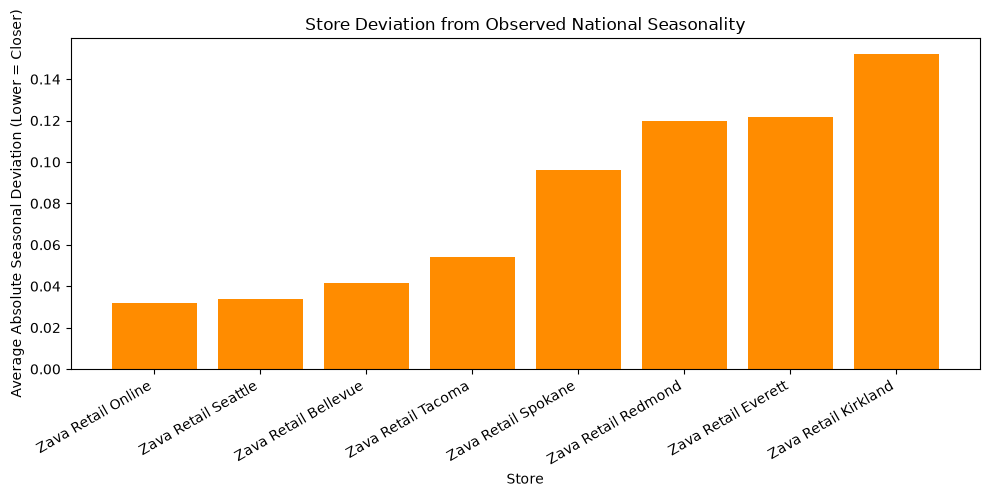

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(
    store_pattern_df['store_name'],
    store_pattern_df['average_absolute_seasonal_deviation'],
    color='darkorange'
)
plt.title('Store Deviation from Observed National Seasonality')
plt.xlabel('Store')
plt.ylabel('Average Absolute Seasonal Deviation (Lower = Closer)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3) 2023 Sales Snapshot

This is actual 2023 performance by store, category, and calendar month. The result includes zero-sales combinations as zero, so every store/category/month is represented. It is a historical view, not a normalized seasonal comparison.

In [87]:
year_2023_sql = """
WITH monthly_sales AS (
    SELECT
        s.store_id,
        s.store_name,
        c.category_id,
        c.category_name,
        EXTRACT(MONTH FROM o.order_date)::int AS month_num,
        SUM(oi.quantity) AS units_sold,
        SUM(oi.total_amount) AS revenue
    FROM retail.orders o
    JOIN retail.order_items oi
      ON oi.order_id = o.order_id
    JOIN retail.products p
      ON p.product_id = oi.product_id
    JOIN retail.categories c
      ON c.category_id = p.category_id
    JOIN retail.stores s
      ON s.store_id = o.store_id
    WHERE o.order_date >= DATE '2023-01-01'
      AND o.order_date < DATE '2024-01-01'
    GROUP BY s.store_id, s.store_name, c.category_id, c.category_name,
             EXTRACT(MONTH FROM o.order_date)::int
),
month_names AS (
    SELECT * FROM (VALUES
        (1, 'Jan'), (2, 'Feb'), (3, 'Mar'), (4, 'Apr'),
        (5, 'May'), (6, 'Jun'), (7, 'Jul'), (8, 'Aug'),
        (9, 'Sep'), (10, 'Oct'), (11, 'Nov'), (12, 'Dec')
    ) AS m(month_num, month_name)
)
SELECT
    s.store_id,
    s.store_name,
    m.month_num,
    m.month_name,
    c.category_id,
    c.category_name,
    COALESCE(ms.units_sold, 0) AS units_sold,
    COALESCE(ms.revenue, 0) AS revenue
FROM retail.stores s
CROSS JOIN retail.categories c
CROSS JOIN month_names m
LEFT JOIN monthly_sales ms
  ON ms.store_id = s.store_id
 AND ms.category_id = c.category_id
 AND ms.month_num = m.month_num
ORDER BY s.store_name, m.month_num, c.category_name;
"""
year_2023_df = fetch_query(year_2023_sql)

summary_2023_df = (
    year_2023_df
    .groupby(['store_id', 'store_name', 'month_num', 'month_name', 'category_id', 'category_name'], as_index=False)
    .agg(units_sold=('units_sold', 'sum'), revenue=('revenue', 'sum'))
    .sort_values(['store_name', 'month_num', 'units_sold'], ascending=[True, True, False])
)

store_month_total_df = (
    summary_2023_df
    .groupby(['store_id', 'store_name', 'month_num', 'month_name'], as_index=False)['units_sold']
    .sum()
    .sort_values(['store_name', 'month_num'])
)

from IPython.display import HTML, display
display(HTML(summary_2023_df.to_html(index=False)))
display(HTML(store_month_total_df.to_html(index=False)))

store_id,store_name,month_num,month_name,category_id,category_name,units_sold,revenue
2,Zava Retail Bellevue,1,Jan,9,STORAGE & ORGANIZATION,225,33207.23
2,Zava Retail Bellevue,1,Jan,3,PAINT & FINISHES,181,7088.56
2,Zava Retail Bellevue,1,Jan,6,ELECTRICAL,177,7719.10
2,Zava Retail Bellevue,1,Jan,4,HARDWARE,167,4053.30
2,Zava Retail Bellevue,1,Jan,2,POWER TOOLS,141,31586.00
2,Zava Retail Bellevue,1,Jan,7,PLUMBING,140,5743.48
2,Zava Retail Bellevue,1,Jan,8,GARDEN & OUTDOOR,125,4344.43
2,Zava Retail Bellevue,1,Jan,5,LUMBER & BUILDING MATERIALS,99,3527.00
2,Zava Retail Bellevue,1,Jan,1,HAND TOOLS,89,2786.26
2,Zava Retail Bellevue,2,Feb,9,STORAGE & ORGANIZATION,214,29134.52


store_id,store_name,month_num,month_name,units_sold
2,Zava Retail Bellevue,1,Jan,1344
2,Zava Retail Bellevue,2,Feb,1397
2,Zava Retail Bellevue,3,Mar,1324
2,Zava Retail Bellevue,4,Apr,1493
2,Zava Retail Bellevue,5,May,1340
2,Zava Retail Bellevue,6,Jun,1305
2,Zava Retail Bellevue,7,Jul,1572
2,Zava Retail Bellevue,8,Aug,1379
2,Zava Retail Bellevue,9,Sep,1373
2,Zava Retail Bellevue,10,Oct,1499


## 3b) 2023 Store-by-Month Detail

This is the operational answer to the question: what actually happened in 2023. The table below shows category sales by store and month for the full 2023 period, and the summary table gives the total units sold per store each month across the year.


## 4) Product Affinity and Cross-Sell Signals

The overall table ranks product pairs by distinct orders containing both products. The store/year/season table shows each cohort's top three pairs by share of its orders and includes each pair's overall count and rank, so local preferences can be compared directly with the global leaders. Cohort counts are shown for context; low pair counts should be treated as exploratory signals and checked across years before making bundle decisions.

In [76]:
frequently_bought_sql = """
WITH order_products AS (
    SELECT DISTINCT order_id, product_id
    FROM retail.order_items
),
order_pairs AS (
    SELECT
        op1.order_id,
        op1.product_id AS product_a,
        op2.product_id AS product_b
    FROM order_products op1
    JOIN order_products op2
      ON op1.order_id = op2.order_id
     AND op1.product_id < op2.product_id
)
SELECT
    p1.product_name AS product_a_name,
    p2.product_name AS product_b_name,
    COUNT(DISTINCT op.order_id) AS pair_order_count
FROM order_pairs op
JOIN retail.products p1
  ON p1.product_id = op.product_a
JOIN retail.products p2
  ON p2.product_id = op.product_b
GROUP BY op.product_a, op.product_b, p1.product_name, p2.product_name
ORDER BY pair_order_count DESC, product_a_name, product_b_name
LIMIT 20;
"""
pair_df = fetch_query(frequently_bought_sql)
pair_df

,product_a_name,product_b_name,pair_order_count
0,Level 24-inch,SAE Hex Key Set,86
1,Ratcheting Screwdriver,Locking Pliers 10-inch,84
2,Professional Claw Hammer 16oz,Needle-Nose Pliers 6-inch,83
3,Metric Wrench Set,Level 24-inch,82
4,Phillips Screwdriver Set,Riffler File Set,82
5,Speed Square 7-inch,Metric Hex Key Set,82
6,Combination Wrench Set SAE,Locking Pliers 10-inch,81
7,Precision Screwdriver Kit,Combination Wrench Set SAE,81
8,Professional Claw Hammer 16oz,SAE Hex Key Set,81
9,Finishing Hammer 13oz,Flathead Screwdriver Set,80


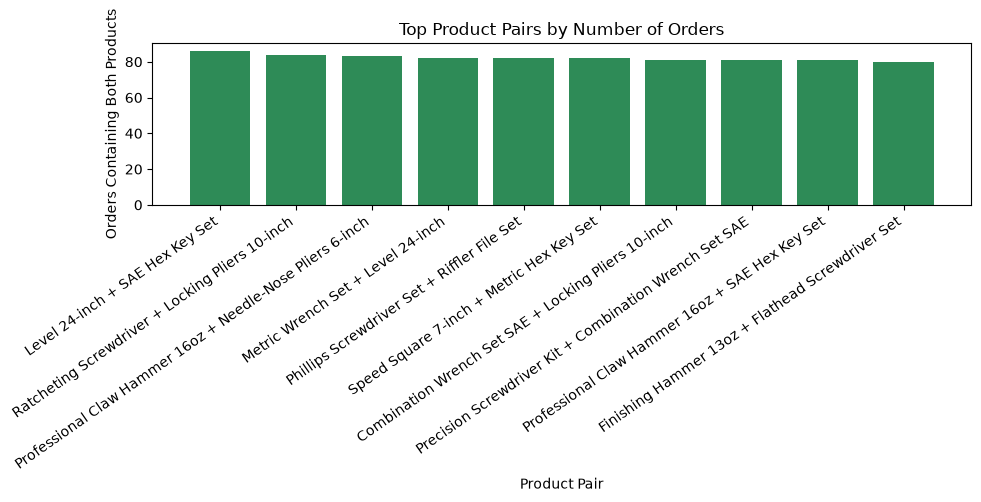

In [77]:
%matplotlib inline
top_pairs = pair_df.head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_pairs['product_a_name'] + ' + ' + top_pairs['product_b_name'], top_pairs['pair_order_count'], color='seagreen')
plt.title('Top Product Pairs by Number of Orders')
plt.xlabel('Product Pair')
plt.ylabel('Orders Containing Both Products')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [26]:
top_3_matrix_sql = """
WITH order_products AS (
    SELECT DISTINCT order_id, product_id
    FROM retail.order_items
),
order_context AS (
    SELECT
        o.order_id,
        s.store_name,
        CASE
            WHEN EXTRACT(MONTH FROM o.order_date)::int IN (12, 1, 2) THEN 'Winter'
            WHEN EXTRACT(MONTH FROM o.order_date)::int IN (3, 4, 5) THEN 'Spring'
            WHEN EXTRACT(MONTH FROM o.order_date)::int IN (6, 7, 8) THEN 'Summer'
            ELSE 'Fall'
        END AS season
    FROM retail.orders o
    JOIN retail.stores s ON s.store_id = o.store_id
),
store_season_pairs AS (
    SELECT
        oc.store_name,
        oc.season,
        op1.product_id AS product_a,
        op2.product_id AS product_b,
        COUNT(DISTINCT oc.order_id) AS pair_count
    FROM order_context oc
    JOIN order_products op1 ON op1.order_id = oc.order_id
    JOIN order_products op2 ON op2.order_id = oc.order_id AND op1.product_id < op2.product_id
    GROUP BY oc.store_name, oc.season, op1.product_id, op2.product_id
),
ranked_pairs AS (
    SELECT
        store_name,
        season,
        product_a,
        product_b,
        pair_count,
        ROW_NUMBER() OVER (
            PARTITION BY store_name, season 
            ORDER BY pair_count DESC
        ) AS rank
    FROM store_season_pairs
)
SELECT
    rp.store_name,
    rp.season,
    rp.rank,
    p1.product_name AS product_a_name,
    p2.product_name AS product_b_name
FROM ranked_pairs rp
JOIN retail.products p1 ON p1.product_id = rp.product_a
JOIN retail.products p2 ON p2.product_id = rp.product_b
WHERE rp.rank <= 3;
"""

# 2. Fetch the data (Will return exactly 96 rows: 8 stores * 4 seasons * 3 ranks)
top_3_df = fetch_query(top_3_matrix_sql)

# 3. Format the pairs into a single readable string per row
top_3_df['formatted_pair'] = top_3_df['rank'].astype(str) + ". " + top_3_df['product_a_name'] + " + " + top_3_df['product_b_name']

# 4. Group the top 3 into a single text block per store/season
grouped_df = top_3_df.groupby(['store_name', 'season'])['formatted_pair'].apply(lambda x: ' | '.join(x)).reset_index()

# 5. Pivot into the 8x4 matrix
matrix_df = grouped_df.pivot(
    index='store_name', 
    columns='season', 
    values='formatted_pair'
)

# Reorder columns chronologically
matrix_df = matrix_df[['Spring', 'Summer', 'Fall', 'Winter']]

# Optional: To make the dataframe cells wrap text nicely in Jupyter, run this display setting:
pd.set_option('display.max_colwidth', None)
matrix_df

season,Spring,Summer,Fall,Winter
store_name,,,,
Zava Retail Bellevue,1. Drywall Primer + Matte Finish Spray Paint | 2. Hanging Basket Planter + Herb Garden Seed Set | 3. Riffler File Set + T-Handle Hex Set,1. Digital Caliper 6-inch + Long Arm Hex Set | 2. Finishing Hammer 13oz + Metric Hex Key Set | 3. Adjustable Wrench 10-inch + Torque Wrench 1/2-drive,1. Phillips Screwdriver Set + Long Arm Hex Set | 2. Wooden Barrel Planter + Anvil Pruners Heavy Duty | 3. Combination Wrench Set SAE + SAE Hex Key Set,1. Phillips Screwdriver Set + Riffler File Set | 2. Insulated Screwdriver Set + Pipe Wrench Set | 3. Phillips Screwdriver Set + SAE Hex Key Set
Zava Retail Everett,1. Circular Saw 7-1/4 inch + File Belt Sander | 2. LED Flood Light 30W + Solar Deck Light Set | 3. Self-Tapping Screws + Furniture Caster Set,1. Adjustable Wrench 10-inch + Ball-End Hex Set | 2. Needle-Nose Pliers 6-inch + SAE Hex Key Set | 3. Fiberglass Batts R-13 + Poplar Board 1x6x8,1. Pre-Insulated Copper Pipe + Pipe Insulation 3/4-inch | 2. Flexible PVC Pipe + Pre-Insulated Copper Pipe | 3. Flathead Screwdriver Set + Level 24-inch,1. Ball Peen Hammer 12oz + Ball-End Hex Set | 2. Insulated Screwdriver Set + Speed Square 7-inch | 3. Sledge Hammer 3lb + Adjustable Wrench 10-inch
Zava Retail Kirkland,1. Underground Wire 12-2 + Rigid Conduit 1-inch | 2. Organic Compost 40lb + Plastic Planter Set | 3. Stackable Bin Set + Garage Workbench Kit,1. Coping Saw + Riffler File Set | 2. Flathead Screwdriver Set + Locking Pliers 10-inch | 3. Needle-Nose Pliers 6-inch + Level 24-inch,1. One-Coat Interior Paint + Solid Color Deck Stain | 2. AFCI Outlet 15-Amp + EMT Conduit 1/2-inch | 3. Hardwood Mulch 2 Cu Ft + Cactus Potting Mix,1. Small Parts Organizer + Retractable Hose Hanger | 2. Pegboard Panel 4x8 + Metal Locker 2-Door | 3. Finishing Hammer 13oz + Digital Caliper 6-inch
Zava Retail Online,1. Sledge Hammer 3lb + Needle-Nose Pliers 6-inch | 2. Pipe Wrench Set + Ball-End Hex Set | 3. Professional Claw Hammer 16oz + Level 24-inch,1. Metric Wrench Set + Ball-End Hex Set | 2. Tomato Plant Food + Slow Release Granules | 3. Locking Pliers 10-inch + Tape Measure 25-foot,1. Flathead Screwdriver Set + Precision Screwdriver Kit | 2. Professional Claw Hammer 16oz + Ratcheting Screwdriver | 3. Phillips Screwdriver Set + Wood Rasp Set,1. Pipe Wrench Set + Needle-Nose Pliers 6-inch | 2. Flathead Screwdriver Set + Insulated Screwdriver Set | 3. Insulated Screwdriver Set + Wire Stripping Pliers
Zava Retail Redmond,1. Metric Wrench Set + Wood Rasp Set | 2. Metric Wrench Set + Digital Caliper 6-inch | 3. Drywall Primer + Clear Polyurethane Satin,1. Tape Measure 25-foot + Ball-End Hex Set | 2. Gloss Spray Paint + Oil-Based Wood Stain | 3. Precision Screwdriver Kit + Speed Square 7-inch,1. Rolling Tool Chest 26-inch + Adjustable Height Workbench | 2. Wood Rasp Set + Level 24-inch | 3. GFCI Outlet 20-Amp + Rigid Conduit 1-inch,1. Flathead Screwdriver Set + Speed Square 7-inch | 2. Flathead Screwdriver Set + Metric Hex Key Set | 3. Ball Peen Hammer 12oz + Metric Hex Key Set
Zava Retail Seattle,1. Needle-Nose Pliers 6-inch + Metric Hex Key Set | 2. Lineman's Pliers 9-inch + Speed Square 7-inch | 3. Phillips Screwdriver Set + Needle-Nose Pliers 6-inch,1. Ball Peen Hammer 12oz + Metric Hex Key Set | 2. Flathead Screwdriver Set + Coping Saw | 3. Phillips Screwdriver Set + Digital Caliper 6-inch,1. Sledge Hammer 3lb + Digital Caliper 6-inch | 2. Ball Peen Hammer 12oz + Wire Stripping Pliers | 3. Precision Screwdriver Kit + Pipe Wrench Set,1. Metric Wrench Set + Pipe Wrench Set | 2. Metal Pegboard Gray + Mobile Work Cart | 3. Precision Screwdriver Kit + Combination Wrench Set SAE
Zava Retail Spokane,1. Professional Claw Hammer 16oz + Torque Wrench 1/2-drive | 2. Ratcheting Screwdriver + Riffler File Set | 3. Finishing Hammer 13oz + Riffler File Set,1. Finishing Hammer 13oz + Level 24-inch | 2. Flathead Screwdriver Set + Tape Measure 25-foot | 3. Finishing Hammer 13oz + Riffler File Set,1. Microfiber Roll

## 5) Completed-Year Demand vs. Available Inventory Snapshot

This compares each completed calendar year's store/category unit sales with the inventory snapshot currently available in `retail.inventory`. The current year is excluded. The schema has no inventory date or history, so this is not a historical inventory count: the same available stock snapshot is compared with each completed year's demand. Positive gaps indicate relative excess; negative gaps indicate relative under-allocation against proportional-to-demand stock. Pairwise transfer quantities are alternatives, not additive recommendations. Very high months-of-supply values also require validating inventory units and business targets before action.

In [26]:
inventory_history_columns_df = fetch_query("""
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_schema = 'retail'
  AND table_name = 'inventory'
ORDER BY ordinal_position;
""")
display(inventory_history_columns_df)
print('The inventory table has no date/year field; the analysis below compares its available snapshot with completed sales years.')

inventory_alignment_sql = """
WITH complete_years AS (
    SELECT EXTRACT(YEAR FROM order_date)::int AS year_num
    FROM retail.orders
    WHERE order_date < DATE_TRUNC('year', CURRENT_DATE)::date
    GROUP BY EXTRACT(YEAR FROM order_date)::int
    HAVING COUNT(DISTINCT EXTRACT(MONTH FROM order_date)) = 12
),
annual_store_category_sales AS (
    SELECT
        o.store_id,
        p.category_id,
        EXTRACT(YEAR FROM o.order_date)::int AS year_num,
        SUM(oi.quantity)::numeric AS units_sold_in_year
    FROM retail.orders o
    JOIN retail.order_items oi
      ON oi.order_id = o.order_id
    JOIN retail.products p
      ON p.product_id = oi.product_id
    JOIN complete_years y
      ON y.year_num = EXTRACT(YEAR FROM o.order_date)::int
    GROUP BY o.store_id, p.category_id, EXTRACT(YEAR FROM o.order_date)::int
),
store_category_inventory_snapshot AS (
    SELECT
        i.store_id,
        p.category_id,
        SUM(i.stock_level)::numeric AS inventory_snapshot_units
    FROM retail.inventory i
    JOIN retail.products p
      ON p.product_id = i.product_id
    GROUP BY i.store_id, p.category_id
),
store_category_year_grid AS (
    SELECT
        s.store_id,
        s.store_name,
        c.category_id,
        c.category_name,
        y.year_num,
        COALESCE(sales.units_sold_in_year, 0) AS units_sold_in_year,
        COALESCE(inv.inventory_snapshot_units, 0) AS inventory_snapshot_units
    FROM retail.stores s
    CROSS JOIN retail.categories c
    CROSS JOIN complete_years y
    LEFT JOIN annual_store_category_sales sales
      ON sales.store_id = s.store_id
     AND sales.category_id = c.category_id
     AND sales.year_num = y.year_num
    LEFT JOIN store_category_inventory_snapshot inv
      ON inv.store_id = s.store_id
     AND inv.category_id = c.category_id
),
category_year_totals AS (
    SELECT
        category_id,
        year_num,
        SUM(units_sold_in_year) AS network_units_sold_in_year,
        SUM(inventory_snapshot_units) AS network_inventory_snapshot_units
    FROM store_category_year_grid
    GROUP BY category_id, year_num
)
SELECT
    g.store_id,
    g.store_name,
    g.category_id,
    g.category_name,
    g.year_num,
    g.units_sold_in_year,
    g.inventory_snapshot_units,
    ROUND(
        100.0 * g.units_sold_in_year
        / NULLIF(t.network_units_sold_in_year, 0),
        2
    ) AS annual_demand_share_pct,
    ROUND(
        100.0 * g.inventory_snapshot_units
        / NULLIF(t.network_inventory_snapshot_units, 0),
        2
    ) AS inventory_snapshot_share_pct,
    t.network_inventory_snapshot_units
        * g.units_sold_in_year
        / NULLIF(t.network_units_sold_in_year, 0) AS proportional_snapshot_units_for_year_demand,
    g.inventory_snapshot_units
        - t.network_inventory_snapshot_units
          * g.units_sold_in_year
          / NULLIF(t.network_units_sold_in_year, 0) AS snapshot_gap_vs_year_demand_units,
    g.inventory_snapshot_units
        / NULLIF(g.units_sold_in_year / 12.0, 0) AS snapshot_months_of_supply_at_yearly_sales_rate
FROM store_category_year_grid g
JOIN category_year_totals t
  ON t.category_id = g.category_id
 AND t.year_num = g.year_num
WHERE t.network_units_sold_in_year > 0
  AND t.network_inventory_snapshot_units > 0
ORDER BY g.year_num, g.category_name, g.store_name;
"""
inventory_position_by_year_df = fetch_query(inventory_alignment_sql)

annual_donors_df = inventory_position_by_year_df.loc[
    inventory_position_by_year_df['snapshot_gap_vs_year_demand_units'] > 0
].rename(columns={
    'store_id': 'donor_store_id',
    'store_name': 'donor_store',
    'inventory_snapshot_units': 'donor_snapshot_units',
    'units_sold_in_year': 'donor_units_sold_in_year',
    'annual_demand_share_pct': 'donor_demand_share_pct',
    'inventory_snapshot_share_pct': 'donor_inventory_share_pct',
    'snapshot_gap_vs_year_demand_units': 'donor_excess_vs_year_demand_units',
    'snapshot_months_of_supply_at_yearly_sales_rate': 'donor_snapshot_months_of_supply'
})
annual_receivers_df = inventory_position_by_year_df.loc[
    inventory_position_by_year_df['snapshot_gap_vs_year_demand_units'] < 0
].rename(columns={
    'store_id': 'recipient_store_id',
    'store_name': 'recipient_store',
    'inventory_snapshot_units': 'recipient_snapshot_units',
    'units_sold_in_year': 'recipient_units_sold_in_year',
    'annual_demand_share_pct': 'recipient_demand_share_pct',
    'inventory_snapshot_share_pct': 'recipient_inventory_share_pct',
    'snapshot_gap_vs_year_demand_units': 'recipient_gap_vs_year_demand_units',
    'snapshot_months_of_supply_at_yearly_sales_rate': 'recipient_snapshot_months_of_supply'
})
candidate_transfers_by_year_df = annual_donors_df.merge(
    annual_receivers_df,
    on=['category_id', 'category_name', 'year_num']
)
candidate_transfers_by_year_df = candidate_transfers_by_year_df.loc[
    candidate_transfers_by_year_df['donor_store_id'] != candidate_transfers_by_year_df['recipient_store_id']
].copy()
candidate_transfers_by_year_df['pairwise_candidate_transfer_units'] = candidate_transfers_by_year_df.apply(
    lambda row: int(min(
        row['donor_excess_vs_year_demand_units'],
        -row['recipient_gap_vs_year_demand_units']
    )),
    axis=1
)
candidate_transfers_by_year_df = (
    candidate_transfers_by_year_df.loc[
        candidate_transfers_by_year_df['pairwise_candidate_transfer_units'] > 0
    ]
    .sort_values(['year_num', 'pairwise_candidate_transfer_units'], ascending=[False, False])
)

display(inventory_position_by_year_df.sort_values(
    ['year_num', 'category_name', 'snapshot_gap_vs_year_demand_units'],
    ascending=[False, True, False]
))
display(candidate_transfers_by_year_df[[
    'year_num',
    'category_name',
    'donor_store',
    'donor_snapshot_units',
    'donor_units_sold_in_year',
    'donor_snapshot_months_of_supply',
    'donor_demand_share_pct',
    'donor_inventory_share_pct',
    'recipient_store',
    'recipient_snapshot_units',
    'recipient_units_sold_in_year',
    'recipient_snapshot_months_of_supply',
    'recipient_demand_share_pct',
    'recipient_inventory_share_pct',
    'pairwise_candidate_transfer_units'
]].head(30))

,column_name,data_type
0,store_id,integer
1,product_id,integer
2,stock_level,integer


The inventory table has no date/year field; the analysis below compares its available snapshot with completed sales years.


,store_id,store_name,category_id,category_name,year_num,units_sold_in_year,inventory_snapshot_units,annual_demand_share_pct,inventory_snapshot_share_pct,proportional_snapshot_units_for_year_demand,snapshot_gap_vs_year_demand_units,snapshot_months_of_supply_at_yearly_sales_rate
364,6,Zava Retail Redmond,6,ELECTRICAL,2025,334,23014,2.83,5.12,12720.9253453097195153,10293.0746546902804847,826.8502994011976058
361,5,Zava Retail Everett,6,ELECTRICAL,2025,370,24381,3.14,5.42,14092.0430471993898822,10288.9569528006101178,790.7351351351351360
366,4,Zava Retail Spokane,6,ELECTRICAL,2025,529,29230,4.48,6.50,20147.812897212101,9082.187102787899,663.0623818525519854
362,7,Zava Retail Kirkland,6,ELECTRICAL,2025,173,14193,1.47,3.16,6588.9822896364714855,7604.0177103635285145,984.4855491329479746
367,3,Zava Retail Tacoma,6,ELECTRICAL,2025,1494,60643,12.66,13.49,56901.384628421320,3741.615371578680,487.0923694779116466
...,...,...,...,...,...,...,...,...,...,...,...,...
66,7,Zava Retail Kirkland,9,STORAGE & ORGANIZATION,2020,89,12385,1.07,3.00,4427.9538331726133076,7957.0461668273866924,1669.8876404494381947
70,4,Zava Retail Spokane,9,STORAGE & ORGANIZATION,2020,362,23839,4.36,5.78,18010.329074252652,5828.670925747348,790.2430939226519328
64,2,Zava Retail Bellevue,9,STORAGE & ORGANIZATION,2020,1539,79218,18.55,19.19,76568.774710703954,2649.225289296046,617.6842105263157895
67,8,Zava Retail Online,9,STORAGE & ORGANIZATION,2020,2374,103103,28.62,24.98,118111.937078109932,-15008.937078109932,521.1609098567818030


,year_num,category_name,donor_store,donor_snapshot_units,donor_units_sold_in_year,donor_snapshot_months_of_supply,donor_demand_share_pct,donor_inventory_share_pct,recipient_store,recipient_snapshot_units,recipient_units_sold_in_year,recipient_snapshot_months_of_supply,recipient_demand_share_pct,recipient_inventory_share_pct,pairwise_candidate_transfer_units
653,2025,HAND TOOLS,Zava Retail Tacoma,54434,1473,443.4541751527494908,13.39,20.55,Zava Retail Seattle,53651,3116,206.6148908857509627,28.33,20.26,18968
679,2025,LUMBER & BUILDING MATERIALS,Zava Retail Tacoma,79091,1613,588.4017358958462491,13.28,17.31,Zava Retail Online,88726,3457,307.9872722013306335,28.46,19.42,18425
721,2025,POWER TOOLS,Zava Retail Tacoma,76548,1617,568.0742115027829314,12.51,15.77,Zava Retail Online,116155,3667,380.1090809926370330,28.37,23.92,15797
722,2025,POWER TOOLS,Zava Retail Tacoma,76548,1617,568.0742115027829314,12.51,15.77,Zava Retail Seattle,112021,3649,368.3891477117018362,28.23,23.07,15797
705,2025,PLUMBING,Zava Retail Tacoma,70562,1466,577.5879945429740790,12.71,16.13,Zava Retail Bellevue,67699,2299,353.3658112222705525,19.93,15.48,14987
664,2025,HARDWARE,Zava Retail Tacoma,68083,1534,532.5919165580182531,12.65,16.15,Zava Retail Online,92098,3529,313.1697364692547464,29.09,21.85,14782
652,2025,HAND TOOLS,Zava Retail Tacoma,54434,1473,443.4541751527494908,13.39,20.55,Zava Retail Online,57486,2989,230.7902308464369355,27.17,21.71,14481
687,2025,PAINT & FINISHES,Zava Retail Redmond,25929,314,990.9171974522292981,2.31,4.79,Zava Retail Online,130430,3921,399.1736801836266259,28.86,24.07,13406
688,2025,PAINT & FINISHES,Zava Retail Redmond,25929,314,990.9171974522292981,2.31,4.79,Zava Retail Seattle,128925,3674,421.0941752857920522,27.04,23.79,13406
665,2025,HARDWARE,Zava Retail Tacoma,68083,1534,532.5919165580182531,12.65,16.15,Zava Retail Seattle,97712,3197,366.7638411010322177,26.36,23.18,13370


In [28]:
annual_donor_rows = inventory_position_by_year_df.loc[
    inventory_position_by_year_df.groupby(['category_id', 'year_num'])[
        'snapshot_gap_vs_year_demand_units'
    ].idxmax(),
    [
        'category_id',
        'category_name',
        'year_num',
        'store_name',
        'inventory_snapshot_units',
        'units_sold_in_year',
        'snapshot_gap_vs_year_demand_units',
        'snapshot_months_of_supply_at_yearly_sales_rate'
    ]
].rename(columns={
    'store_name': 'largest_relative_stock_store',
    'inventory_snapshot_units': 'largest_store_snapshot_units',
    'units_sold_in_year': 'largest_store_units_sold_in_year',
    'snapshot_gap_vs_year_demand_units': 'largest_positive_gap_units',
    'snapshot_months_of_supply_at_yearly_sales_rate': 'largest_store_snapshot_months_of_supply'
})
annual_recipient_rows = inventory_position_by_year_df.loc[
    inventory_position_by_year_df.groupby(['category_id', 'year_num'])[
        'snapshot_gap_vs_year_demand_units'
    ].idxmin(),
    [
        'category_id',
        'category_name',
        'year_num',
        'store_name',
        'inventory_snapshot_units',
        'units_sold_in_year',
        'snapshot_gap_vs_year_demand_units',
        'snapshot_months_of_supply_at_yearly_sales_rate'
    ]
].rename(columns={
    'store_name': 'lowest_relative_stock_store',
    'inventory_snapshot_units': 'lowest_store_snapshot_units',
    'units_sold_in_year': 'lowest_store_units_sold_in_year',
    'snapshot_gap_vs_year_demand_units': 'largest_negative_gap_units',
    'snapshot_months_of_supply_at_yearly_sales_rate': 'lowest_store_snapshot_months_of_supply'
})
annual_inventory_imbalance_df = (
    annual_donor_rows
    .merge(annual_recipient_rows, on=['category_id', 'category_name', 'year_num'])
    .sort_values(['year_num', 'largest_positive_gap_units'], ascending=[False, False])
)
display(annual_inventory_imbalance_df.drop(columns='category_id'))

,category_name,year_num,largest_relative_stock_store,largest_store_snapshot_units,largest_store_units_sold_in_year,largest_positive_gap_units,largest_store_snapshot_months_of_supply,lowest_relative_stock_store,lowest_store_snapshot_units,lowest_store_units_sold_in_year,largest_negative_gap_units,lowest_store_snapshot_months_of_supply
5,HAND TOOLS,2025,Zava Retail Tacoma,54434,1473,18968.043363636364,443.4541751527494908,Zava Retail Seattle,53651,3116,-21374.065090909091,206.6148908857509627
29,LUMBER & BUILDING MATERIALS,2025,Zava Retail Tacoma,79091,1613,18425.893389314234,588.4017358958462491,Zava Retail Online,88726,3457,-41292.148514036388,307.9872722013306335
11,POWER TOOLS,2025,Zava Retail Tacoma,76548,1617,15797.395078922934,568.0742115027829314,Zava Retail Seattle,112021,3649,-25071.738006809037,368.3891477117018362
41,PLUMBING,2025,Zava Retail Tacoma,70562,1466,14987.677039091618,577.5879945429740790,Zava Retail Bellevue,67699,2299,-19453.365953020716,353.3658112222705525
23,HARDWARE,2025,Zava Retail Tacoma,68083,1534,14782.759934047815,532.5919165580182531,Zava Retail Online,92098,3529,-30520.348887056884,313.1697364692547464
17,PAINT & FINISHES,2025,Zava Retail Redmond,25929,314,13406.7160521086332524,990.9171974522292981,Zava Retail Online,130430,3921,-25939.029807904615,399.1736801836266259
53,STORAGE & ORGANIZATION,2025,Zava Retail Tacoma,65286,1512,11574.799380325329,518.1428571428571429,Zava Retail Seattle,84246,3146,-27510.241500989758,321.3452002542911633
35,ELECTRICAL,2025,Zava Retail Redmond,23014,334,10293.0746546902804847,826.8502994011976058,Zava Retail Seattle,104574,3341,-22673.340055927464,375.6025142173002095
47,GARDEN & OUTDOOR,2025,Zava Retail Tacoma,65702,1574,8379.697564457133,500.9047013977128334,Zava Retail Seattle,86893,3019,-23053.652511374788,345.3845644253063929
4,HAND TOOLS,2024,Zava Retail Tacoma,54434,1464,16449.883228840125,446.1803278688524590,Zava Retail Seattle,53651,2824,-19618.908307210031,227.9787535410764873


## 6 Which products have the widest gap between inventory levels and sales velocity?


In [11]:
query = """
WITH latest_data AS (
    SELECT MAX(order_date)::date AS latest_order_date
    FROM retail.orders
),
product_sales AS (
    SELECT
        oi.product_id,
        SUM(oi.quantity)::numeric AS units_sold_last_12_months
    FROM retail.order_items oi
    JOIN retail.orders o
      ON o.order_id = oi.order_id
    CROSS JOIN latest_data d
    WHERE o.order_date >= d.latest_order_date - INTERVAL '12 months'
      AND o.order_date < d.latest_order_date + INTERVAL '1 day'
    GROUP BY oi.product_id
),
product_inventory AS (
    SELECT
        product_id,
        SUM(stock_level)::numeric AS total_stock_units
    FROM retail.inventory
    GROUP BY product_id
),
product_metrics AS (
    SELECT
        p.product_id,
        p.product_name,
        COALESCE(pi.total_stock_units, 0) AS total_stock_units,
        COALESCE(ps.units_sold_last_12_months, 0) AS units_sold_last_12_months,
        COALESCE(ps.units_sold_last_12_months, 0) / 12.0 AS average_monthly_sales_units,
        COALESCE(pi.total_stock_units, 0)
            / NULLIF(COALESCE(ps.units_sold_last_12_months, 0) / 12.0, 0)
            AS months_of_supply_for_sorting
    FROM retail.products p
    LEFT JOIN product_sales ps
      ON ps.product_id = p.product_id
    LEFT JOIN product_inventory pi
      ON pi.product_id = p.product_id
)
SELECT
    product_id,
    product_name,
    total_stock_units,
    units_sold_last_12_months,
    ROUND(average_monthly_sales_units, 1) AS average_units_sold_per_month,
    CASE
        WHEN units_sold_last_12_months <= 0
            THEN 'No sales recorded in the last 12 months'
        ELSE 'About '
            || TO_CHAR(ROUND(average_monthly_sales_units, 1), 'FM999999990.0')
            || ' units sold per month'
    END AS sales_velocity_readout,
    CASE
        WHEN total_stock_units <= 0
            THEN 'No stock recorded'
        WHEN units_sold_last_12_months <= 0
            THEN 'Stock on hand, but no sales in the last 12 months'
        WHEN months_of_supply_for_sorting > 60
            THEN 'Over 5 years of stock at the recent sales rate'
        WHEN months_of_supply_for_sorting > 12
            THEN 'About 1–5 years of stock at the recent sales rate'
        WHEN months_of_supply_for_sorting > 6
            THEN 'About 6–12 months of stock at the recent sales rate'
        WHEN months_of_supply_for_sorting > 3
            THEN 'About 3–6 months of stock at the recent sales rate'
        WHEN months_of_supply_for_sorting > 1
            THEN 'About 1–3 months of stock at the recent sales rate'
        ELSE 'Less than 1 month of stock at the recent sales rate'
    END AS stock_coverage_readout
FROM product_metrics
ORDER BY
    CASE
        WHEN units_sold_last_12_months = 0 AND total_stock_units > 0 THEN 1
        WHEN months_of_supply_for_sorting > 6 THEN 2
        WHEN months_of_supply_for_sorting > 3 THEN 3
        WHEN total_stock_units <= 0 AND units_sold_last_12_months > 0 THEN 4
        ELSE 5
    END,
    months_of_supply_for_sorting DESC NULLS LAST,
    units_sold_last_12_months ASC
LIMIT 20;
"""

inventory_gap_df = fetch_query(query)
inventory_gap_df

,product_id,product_name,total_stock_units,units_sold_last_12_months,average_units_sold_per_month,sales_velocity_readout,stock_coverage_readout
0,97,Natural Bristle Brush Set,15225,262,21.8,About 21.8 units sold per month,Over 5 years of stock at the recent sales rate
1,328,Heavy Duty Teflon Tape,13805,241,20.1,About 20.1 units sold per month,Over 5 years of stock at the recent sales rate
2,88,Exterior Primer-Paint Combo,14293,254,21.2,About 21.2 units sold per month,Over 5 years of stock at the recent sales rate
3,265,Grease Cap Wire Nuts,14509,260,21.7,About 21.7 units sold per month,Over 5 years of stock at the recent sales rate
4,206,OSB Siding Panel,11735,211,17.6,About 17.6 units sold per month,Over 5 years of stock at the recent sales rate
5,99,Foam Brush Set,13322,240,20.0,About 20.0 units sold per month,Over 5 years of stock at the recent sales rate
6,369,Pole Saw Pruner 8-foot,14141,260,21.7,About 21.7 units sold per month,Over 5 years of stock at the recent sales rate
7,381,Wire Shelving Chrome,12285,226,18.8,About 18.8 units sold per month,Over 5 years of stock at the recent sales rate
8,154,Strap Hinge Heavy Duty,13190,244,20.3,About 20.3 units sold per month,Over 5 years of stock at the recent sales rate
9,315,Plunger Set,13360,248,20.7,About 20.7 units sold per month,Over 5 years of stock at the recent sales rate


In [5]:
top_inventory_gap = inventory_gap_df.iloc[0]

# Use this for the inventory problem's "Evidence from current data":
f"{top_inventory_gap['product_name']}: "
f"{int(top_inventory_gap['total_stock_units']):,} units in stock; "
f"{int(top_inventory_gap['units_sold_last_12_months']):,} units sold in the last 12 months; "
f"{top_inventory_gap['sales_velocity_readout']}. "
f"{top_inventory_gap['stock_coverage_readout']}."

'Over 5 years of stock at the recent sales rate.'

## 7) How different does the data look when you query as a single store manager rather than the super manager?

Row-level security (RLS) controls which rows each manager can see. The notebook logs in as `postgres`, a superuser that bypasses RLS, so it would see every store regardless of manager identity. To get a true store-manager view, each query below switches the session to the restricted `store_manager` role (`SET ROLE`) and sets the manager identity, so the database applies the same policies a store manager would face.

The comparison table shows what the super manager and each store manager can see, and the last column confirms each store's numbers against a direct filter on that store. Terms: **Inventory Records** are product-by-store stock rows, **Units in Stock** is the total quantity on hand, and **Units Sold** and **Revenue** cover all order history. Customer counts overlap between stores because a manager sees customers assigned to the store and customers who ordered there, so they do not add up to the network total.

In [13]:
SUPER_MANAGER_UUID = '00000000-0000-0000-0000-000000000000'

def fetch_as_manager(sql, rls_user_id):
    conn = psycopg2.connect(**DB_CONFIG)
    try:
        with conn.cursor(cursor_factory=RealDictCursor) as cur:
            # postgres bypasses RLS; switching to store_manager makes the policies apply.
            cur.execute("SET ROLE store_manager")
            cur.execute("SELECT set_config('app.current_rls_user_id', %s, false)", (rls_user_id,))
            cur.execute(sql)
            rows = cur.fetchall()
    finally:
        conn.close()
    return pd.DataFrame(rows)

stores_df = fetch_query("SELECT store_id, store_name, rls_user_id::text AS rls_user_id FROM retail.stores ORDER BY store_name;")
stores_df.rename(columns={
    'store_id': 'Store ID',
    'store_name': 'Store',
    'rls_user_id': 'Manager Login ID (used by RLS)'
})

,Store ID,Store,Manager Login ID (used by RLS)
0,2,Zava Retail Bellevue,6ba7b810-9dad-11d1-80b4-00c04fd430c8
1,5,Zava Retail Everett,3b9ac9fa-cd5e-4b92-a7f2-b8c1d0e9f2a3
2,7,Zava Retail Kirkland,9c8b7a65-4321-fed0-9876-543210fedcba
3,8,Zava Retail Online,2f4e6d8c-1a3b-5c7e-9f0a-b2d4f6e8c0a2
4,6,Zava Retail Redmond,e7f8a9b0-c1d2-3e4f-5678-90abcdef1234
5,1,Zava Retail Seattle,f47ac10b-58cc-4372-a567-0e02b2c3d479
6,4,Zava Retail Spokane,d8e9f0a1-b2c3-4567-8901-234567890abc
7,3,Zava Retail Tacoma,a1b2c3d4-e5f6-7890-abcd-ef1234567890


In [14]:
login_role = fetch_query("""
SELECT current_user AS database_role, rolsuper, rolbypassrls
FROM pg_roles
WHERE rolname = current_user;
""").iloc[0]

role_status = fetch_as_manager("""
SELECT
    current_user AS database_role,
    r.rolsuper,
    r.rolbypassrls,
    c.relrowsecurity,
    c.relforcerowsecurity,
    pg_get_userbyid(c.relowner) = current_user AS is_table_owner
FROM pg_class c
JOIN pg_namespace n
  ON n.oid = c.relnamespace
JOIN pg_roles r
  ON r.rolname = current_user
WHERE n.nspname = 'retail'
  AND c.relname = 'orders';
""", SUPER_MANAGER_UUID).iloc[0]
rls_is_enforced = (
    not bool(role_status['rolsuper'])
    and not bool(role_status['rolbypassrls'])
    and bool(role_status['relrowsecurity'])
    and (not bool(role_status['is_table_owner']) or bool(role_status['relforcerowsecurity']))
)

MANAGER_METRICS_SQL = """
SELECT
    (SELECT COUNT(*) FROM retail.orders) AS "Orders",
    (SELECT COUNT(*) FROM retail.customers) AS "Customers",
    (SELECT COUNT(*) FROM retail.inventory) AS "Inventory Records",
    (SELECT COALESCE(SUM(stock_level), 0) FROM retail.inventory) AS "Units in Stock",
    (SELECT COALESCE(SUM(quantity), 0) FROM retail.order_items) AS "Units Sold",
    (SELECT COALESCE(SUM(total_amount), 0) FROM retail.order_items) AS "Revenue";
"""

# Direct per-store filter run as postgres; it is the independent check for the RLS result.
STORE_EXPECTED_SQL = """
SELECT
    (SELECT COUNT(*) FROM retail.orders WHERE store_id = %(sid)s) AS "Orders",
    (SELECT COUNT(*) FROM retail.customers c
      WHERE c.primary_store_id = %(sid)s
         OR EXISTS (SELECT 1 FROM retail.orders o
                    WHERE o.customer_id = c.customer_id AND o.store_id = %(sid)s)) AS "Customers",
    (SELECT COUNT(*) FROM retail.inventory WHERE store_id = %(sid)s) AS "Inventory Records",
    (SELECT COALESCE(SUM(stock_level), 0) FROM retail.inventory WHERE store_id = %(sid)s) AS "Units in Stock",
    (SELECT COALESCE(SUM(quantity), 0) FROM retail.order_items WHERE store_id = %(sid)s) AS "Units Sold",
    (SELECT COALESCE(SUM(total_amount), 0) FROM retail.order_items WHERE store_id = %(sid)s) AS "Revenue";
"""

METRIC_COLUMNS = ['Orders', 'Customers', 'Inventory Records', 'Units in Stock', 'Units Sold', 'Revenue']

def as_floats(df):
    return df.iloc[0][METRIC_COLUMNS].apply(float)

def matches(actual, expected):
    return bool(((actual - expected).abs() < 0.01).all())

network_expected = as_floats(fetch_query(MANAGER_METRICS_SQL))
super_view = as_floats(fetch_as_manager(MANAGER_METRICS_SQL, SUPER_MANAGER_UUID))
rows = [{
    'View': 'Super Manager (all stores)',
    **super_view.to_dict(),
    'Matches Direct Check': matches(super_view, network_expected)
}]
for store in stores_df.itertuples():
    store_view = as_floats(fetch_as_manager(MANAGER_METRICS_SQL, store.rls_user_id))
    store_expected = as_floats(fetch_query(STORE_EXPECTED_SQL, {'sid': int(store.store_id)}))
    rows.append({
        'View': f'Store Manager: {store.store_name}',
        **store_view.to_dict(),
        'Matches Direct Check': matches(store_view, store_expected)
    })

rls_comparison_df = pd.DataFrame(rows)
rls_comparison_df['Share of All Orders (%)'] = (
    100 * rls_comparison_df['Orders'] / super_view['Orders']
).round(1)
rls_comparison_df = pd.concat([
    rls_comparison_df.iloc[:1],
    rls_comparison_df.iloc[1:].sort_values('Orders', ascending=False)
], ignore_index=True)

role_summary_df = pd.DataFrame({
    'Check': [
        'Notebook login role',
        'Notebook login can bypass row-level security',
        'Role used for the store-manager view',
        'Store-manager role can bypass row-level security',
        'Row-level security enforced for store-manager view'
    ],
    'Answer': [
        login_role['database_role'],
        'Yes' if (login_role['rolsuper'] or login_role['rolbypassrls']) else 'No',
        role_status['database_role'],
        'Yes' if (role_status['rolsuper'] or role_status['rolbypassrls']) else 'No',
        'Yes' if rls_is_enforced else 'No'
    ]
})

display_df = rls_comparison_df[[
    'View', 'Orders', 'Share of All Orders (%)', 'Customers',
    'Inventory Records', 'Units in Stock', 'Units Sold', 'Revenue', 'Matches Direct Check'
]].copy()
for col in METRIC_COLUMNS:
    display_df[col] = display_df[col].map('{:,.0f}'.format)
display_df['Share of All Orders (%)'] = display_df['Share of All Orders (%)'].map('{:.1f}%'.format)
display_df['Matches Direct Check'] = display_df['Matches Direct Check'].map({True: 'Yes', False: 'No'})

display(role_summary_df)
if not rls_is_enforced:
    print('WARNING: row-level security is not enforced for the store-manager view; the store rows below are not restricted.')

store_rows = rls_comparison_df.iloc[1:]
largest_store, smallest_store = store_rows.iloc[0], store_rows.iloc[-1]
print(
    f"The super manager sees {super_view['Orders']:,.0f} orders across all stores. "
    f"A store manager sees only their own store: from {smallest_store['Orders']:,.0f} orders "
    f"({smallest_store['View'].replace('Store Manager: ', '')}) to {largest_store['Orders']:,.0f} orders "
    f"({largest_store['View'].replace('Store Manager: ', '')})."
)
display(display_df)

,Check,Answer
0,Notebook login role,postgres
1,Notebook login can bypass row-level security,Yes
2,Role used for the store-manager view,store_manager
3,Store-manager role can bypass row-level security,No
4,Row-level security enforced for store-manager ...,Yes


The super manager sees 198,783 orders across all stores. A store manager sees only their own store: from 2,968 orders (Zava Retail Kirkland) to 56,467 orders (Zava Retail Online).


,View,Orders,Share of All Orders (%),Customers,Inventory Records,Units in Stock,Units Sold,Revenue,Matches Direct Check
0,Super Manager (all stores),"198,783",100.0%,"50,000","3,392","3,878,342","675,926","46,680,040",Yes
1,Store Manager: Zava Retail Online,"56,467",28.4%,"20,445",424,"902,892","191,905","13,251,670",Yes
2,Store Manager: Zava Retail Seattle,"54,579",27.5%,"20,157",424,"897,648","186,034","12,763,770",Yes
3,Store Manager: Zava Retail Bellevue,"36,502",18.4%,"17,475",424,"705,678","124,511","8,691,424",Yes
4,Store Manager: Zava Retail Tacoma,"26,426",13.3%,"14,231",424,"619,160","89,735","6,182,049",Yes
5,Store Manager: Zava Retail Spokane,"9,934",5.0%,"6,014",424,"241,358","33,450","2,343,104",Yes
6,Store Manager: Zava Retail Everett,"6,718",3.4%,"5,301",424,"211,113","22,770","1,542,522",Yes
7,Store Manager: Zava Retail Redmond,"5,189",2.6%,"4,570",424,"180,179","17,383","1,191,726",Yes
8,Store Manager: Zava Retail Kirkland,"2,968",1.5%,"2,995",424,"120,314","10,138","713,775",Yes


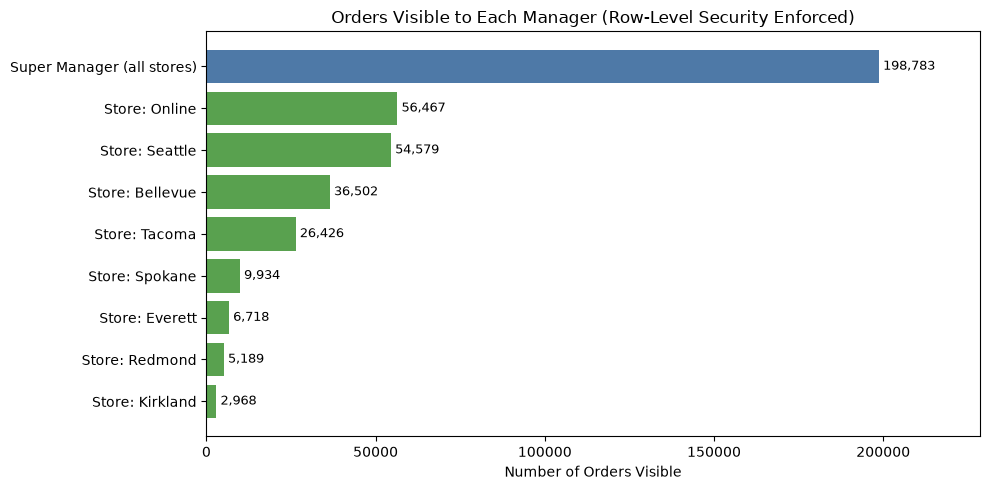

In [15]:
%matplotlib inline
chart_df = rls_comparison_df.copy()
chart_labels = chart_df['View'].str.replace('Store Manager: Zava Retail ', 'Store: ', regex=False)

plt.figure(figsize=(10, 5))
bars = plt.barh(chart_labels, chart_df['Orders'], color=['#4E79A7'] + ['#59A14F'] * (len(chart_df) - 1))
for bar, value in zip(bars, chart_df['Orders']):
    plt.text(value, bar.get_y() + bar.get_height() / 2, f' {value:,.0f}', va='center', fontsize=9)
plt.gca().invert_yaxis()
plt.title(
    'Orders Visible to Each Manager '
    f"(Row-Level Security {'Enforced' if rls_is_enforced else 'NOT Enforced'})"
)
plt.xlabel('Number of Orders Visible')
plt.xlim(0, chart_df['Orders'].max() * 1.15)
plt.tight_layout()
plt.show()

## 8) Candidate Problems to Investigate

These are evidence-backed hypotheses from the current database results, not confirmed root causes. Validate inventory units and security configuration with the system owners before taking operational action.

In [16]:
top_inventory_gap = inventory_gap_df.iloc[0]
top_seasonal = seasonal_df.iloc[0]

candidate_problems_df = pd.DataFrame([
    {
        'Candidate problem': 'Potential inventory overhang or stock/sales unit mismatch',
        'Evidence from current data': (
            f"{top_inventory_gap['product_name']}: {int(top_inventory_gap['total_stock_units']):,} units in stock "
            f"versus {int(top_inventory_gap['units_sold_last_12_months']):,} sold in the latest 12 months. "
            f"{top_inventory_gap['stock_coverage_readout']}."
        ),
        'Next validation': 'Reconcile inventory units, stock snapshots, and product-level sales before changing replenishment.'
    },
    {
        'Candidate problem': 'Seasonal readiness for the strongest seasonal category',
        'Evidence from current data': (
            f"{top_seasonal['category_name']} has the largest normalized swing "
            f"({top_seasonal['seasonal_swing']:.3f}), peaking in {top_seasonal['peak_month']} "
            f"and reaching its low in {top_seasonal['low_month']}."
        ),
        'Next validation': 'Add supplier lead times and order calendars to determine the required advance-buy window.'
    },
    {
        'Candidate problem': 'The notebook login bypasses store-level access controls',
        'Evidence from current data': (
            f"Login role {login_role['database_role']} has superuser={bool(login_role['rolsuper'])} and "
            f"BYPASSRLS={bool(login_role['rolbypassrls'])}, so it sees all {int(super_view['Orders']):,} orders. "
            f"As the store_manager role, a manager sees {int(smallest_store['Orders']):,} to "
            f"{int(largest_store['Orders']):,} orders depending on the store."
        ),
        'Next validation': 'Ensure apps and agents that should be store-scoped connect as a non-superuser role without BYPASSRLS.'
    }
])
display(candidate_problems_df)

,Candidate problem,Evidence from current data,Next validation
0,Potential inventory overhang or stock/sales un...,"Natural Bristle Brush Set: 15,225 units in sto...","Reconcile inventory units, stock snapshots, an..."
1,Seasonal readiness for the strongest seasonal ...,GARDEN & OUTDOOR has the largest normalized sw...,Add supplier lead times and order calendars to...
2,The notebook login bypasses store-level access...,Login role postgres has superuser=True and BYP...,Ensure apps and agents that should be store-sc...
